### HW 5

##### Step 1) Loading and Preprocessing the Data

In [19]:
import pandas as pd
import numpy as np

DATA_DIR = "UCIData/UCI HAR Dataset/"

# Load feature names
features = pd.read_csv(f"{DATA_DIR}/features.txt", sep=r"\s+", header=None, names=["idx", "feature"])
feature_names = features["feature"].tolist()

# Handle duplicate feature names (our 561 features have 84 duplicated column names)
from collections import Counter
counts = Counter()
unique_names = []
for name in feature_names:
    counts[name] += 1
    unique_names.append(f"{name}_{counts[name]}" if counts[name] > 1 else name)
feature_names = unique_names

# Load activity labels (1-6 -> name)
activity_labels = pd.read_csv(f"{DATA_DIR}/activity_labels.txt", sep=r"\s+", header=None, names=["id", "activity"])
activity_map = dict(zip(activity_labels["id"], activity_labels["activity"]))

# Load feature data
X_train = pd.read_csv(f"{DATA_DIR}/train/X_train.txt", sep=r"\s+", header=None)
X_test = pd.read_csv(f"{DATA_DIR}/test/X_test.txt", sep=r"\s+", header=None)
X = pd.concat([X_train, X_test], axis=0).reset_index(drop=True)
X.columns = feature_names

# Load labels
y_train = pd.read_csv(f"{DATA_DIR}/train/y_train.txt", header=None, names=["label"])
y_test = pd.read_csv(f"{DATA_DIR}/test/y_test.txt", header=None, names=["label"])
y = pd.concat([y_train, y_test], axis=0).reset_index(drop=True)["label"]
y_names = y.map(activity_map)

# Scale values for equal-grounds comparison
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


##### Step 2) Dimensionality Reduction

In [20]:
from sklearn.decomposition import PCA

# 2 components for visualization
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)
print("Explained variance (2D):", pca_2d.explained_variance_ratio_, 
      "total:", pca_2d.explained_variance_ratio_.sum())

# 50 components for clustering input
pca_50d = PCA(n_components=50, random_state=42)
X_pca_50d = pca_50d.fit_transform(X_scaled)
print("Explained variance (50D total):", pca_50d.explained_variance_ratio_.sum())

Explained variance (2D): [0.50738221 0.06239186] total: 0.5697740681020983
Explained variance (50D total): 0.8709898472528163


###### Visualization

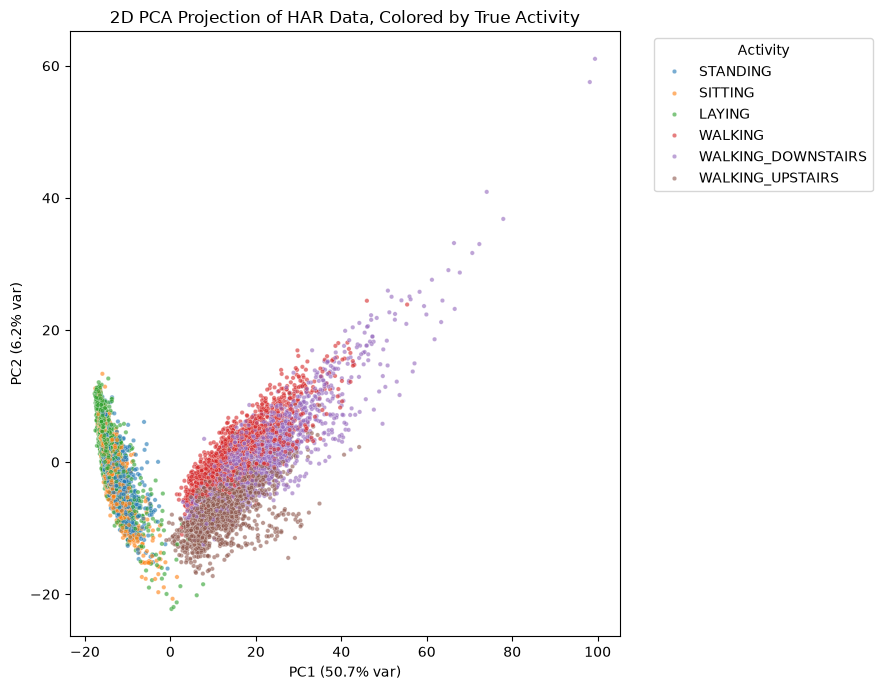

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y_names, palette="tab10", s=10, alpha=0.6)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("2D PCA Projection of HAR Data, Colored by True Activity")
plt.legend(title="Activity", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

##### Part 3) K-Means Clustering

We start with k = 6 for our 50D PCA.

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca_50d)

inertia = kmeans.inertia_
sil_score = silhouette_score(X_pca_50d, cluster_labels)

print(f"Inertia: {inertia:.2f}")
print(f"Silhouette Score: {sil_score:.4f}")

Inertia: 1833594.70
Silhouette Score: 0.1524


###### Visualization

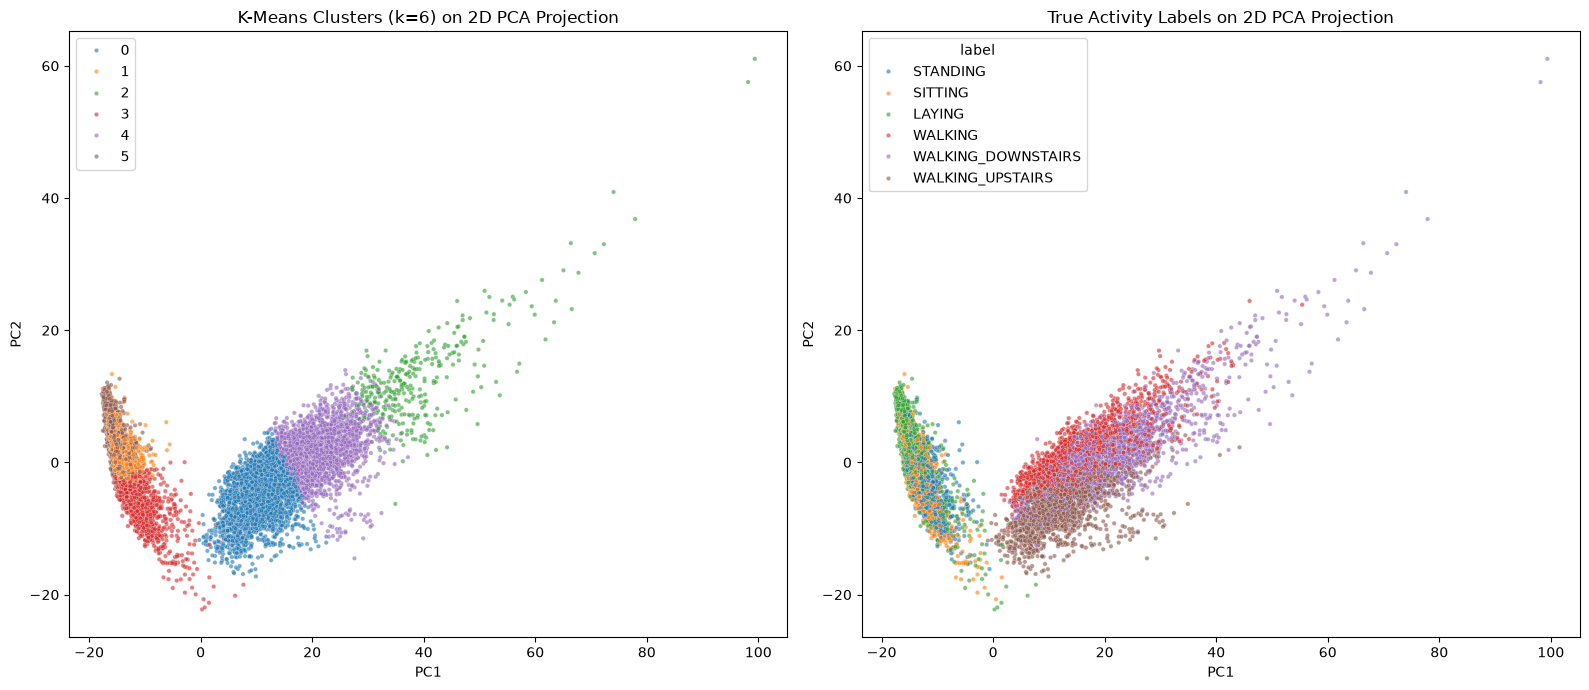

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: colored by K-Means cluster assignment
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=cluster_labels, 
                 palette="tab10", s=10, alpha=0.6, ax=axes[0], legend="full")
axes[0].set_title("K-Means Clusters (k=6) on 2D PCA Projection")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Right: colored by true label, for side-by-side comparison
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y_names, 
                 palette="tab10", s=10, alpha=0.6, ax=axes[1], legend="full")
axes[1].set_title("True Activity Labels on 2D PCA Projection")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

For k = 6 we get
- Inertia: 1833594.70
- Silhouette Score: 0.1524

#### Charting k = 2 through k = 12

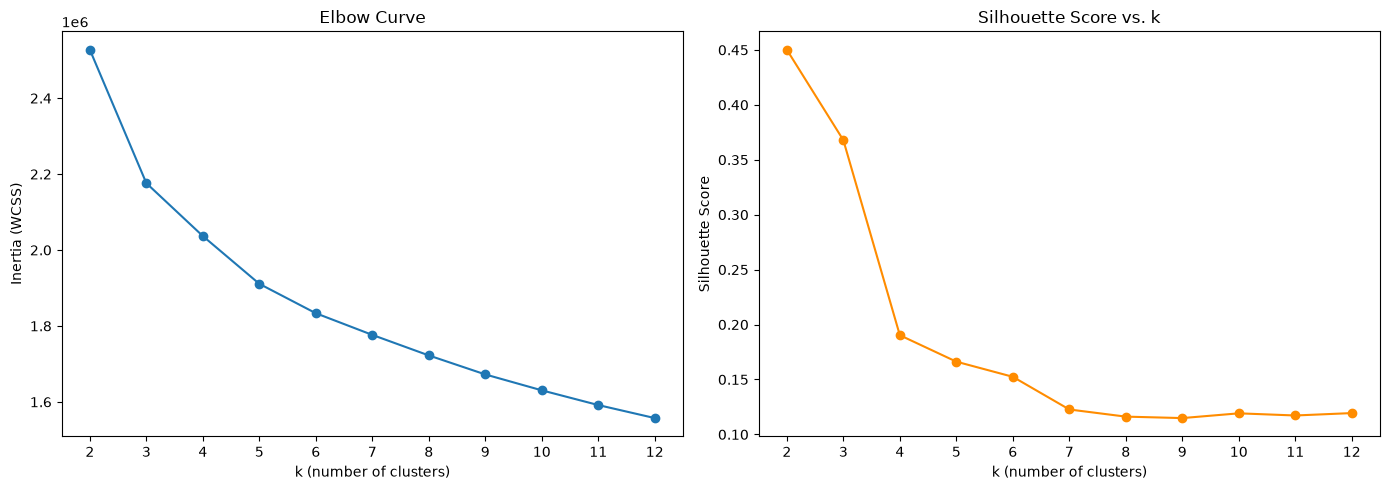

In [24]:
k_range = range(2, 13)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_pca_50d)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca_50d, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Curve")
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), sil_scores, marker='o', color='darkorange')
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs. k")
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

In [25]:
for i in range(len(inertias)):
    print("k: " + str(i + 2) + "\t| inertia: " + str(inertias[i]) + "\t| silhouette score: " + str(sil_scores[i]))

k: 2	| inertia: 2527535.1899491046	| silhouette score: 0.450141968628921
k: 3	| inertia: 2176124.2834791946	| silhouette score: 0.3678458056919922
k: 4	| inertia: 2036867.9026094743	| silhouette score: 0.19029863497666133
k: 5	| inertia: 1911005.096296903	| silhouette score: 0.16623206611171723
k: 6	| inertia: 1833594.7034431815	| silhouette score: 0.15244416720393283
k: 7	| inertia: 1776514.7158580376	| silhouette score: 0.12269980693995933
k: 8	| inertia: 1722452.6049470445	| silhouette score: 0.11619192960574413
k: 9	| inertia: 1672376.2922951458	| silhouette score: 0.11487303144762588
k: 10	| inertia: 1630515.5793570243	| silhouette score: 0.11919316016137155
k: 11	| inertia: 1591719.5688712797	| silhouette score: 0.11723504009683025
k: 12	| inertia: 1557426.4741769596	| silhouette score: 0.11941497640130884


We'll investigate k = 2 to verify it's doing what it seems to be doing -- separating the 2 overlapping "static" and "dynamic" activities. We'll also print the crosstab of k = 6 for comparison.

In [26]:
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels_k2 = kmeans_2.fit_predict(X_pca_50d)

crosstab_k2 = pd.crosstab(cluster_labels_k2, y_names, rownames=["Cluster"], colnames=["True Activity"])
print(crosstab_k2)

crosstab_k6 = pd.crosstab(cluster_labels, y_names, rownames=["Cluster"], colnames=["True Activity"])
print(crosstab_k6)

True Activity  LAYING  SITTING  STANDING  WALKING  WALKING_DOWNSTAIRS  \
Cluster                                                                 
0                1932     1774      1906        0                   0   
1                  12        3         0     1722                1406   

True Activity  WALKING_UPSTAIRS  
Cluster                          
0                             8  
1                          1536  
True Activity  LAYING  SITTING  STANDING  WALKING  WALKING_DOWNSTAIRS  \
Cluster                                                                 
0                   5        1         0      897                 308   
1                  52     1234      1343        0                   0   
2                   0        0         0       85                 214   
3                 329      451       563        0                   0   
4                   0        0         0      740                 884   
5                1558       91         0        0           

#### Step 4) DBSCAN

We'll start by plotting K-Distance to determine a starting point for our eps.

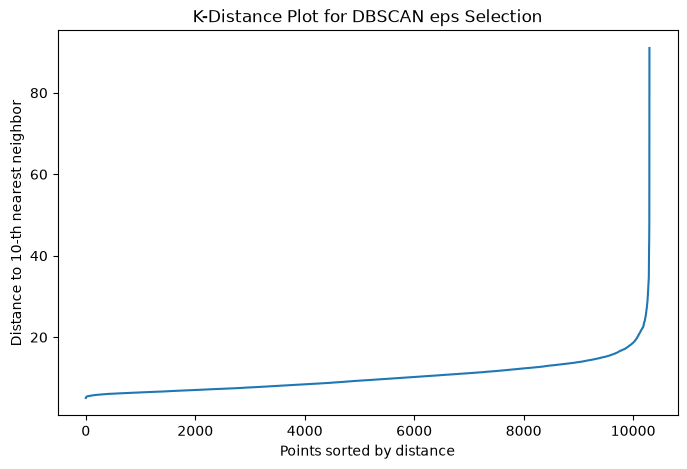

In [27]:
from sklearn.neighbors import NearestNeighbors

min_samples_guess = 10  # roughly 2x the number of PCA dimensions is a common heuristic, but 5-20 is a reasonable range to try
neighbors = NearestNeighbors(n_neighbors=min_samples_guess)
neighbors_fit = neighbors.fit(X_pca_50d)
distances, indices = neighbors_fit.kneighbors(X_pca_50d)

# sort distances to the k-th nearest neighbor
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"Distance to {min_samples_guess}-th nearest neighbor")
plt.title("K-Distance Plot for DBSCAN eps Selection")
plt.show()

##### Exploring to find a reasonable DBSCAN clustering
The elbow at 20 suggested that would be a good place to start searching for good categorizations, but models in that area overwhelming clustered all of our poitns together. I ended up exploring around eps = 10 and added the ratio of 2nd-to-1st-largest-cluster as a filter (and ultimately, for simplicity and to target the static vs dynamic split, just the size of the 2nd cluster).

In [29]:


from collections import Counter
from sklearn.cluster import DBSCAN

results = []

eps_values = [7,9,10,11,13]
min_samples_values = [2,3,5, 10, 15, 20,45]

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels_db = db.fit_predict(X_pca_50d)
        
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_noise = list(labels_db).count(-1)
        
        # cluster sizes, excluding noise (-1)
        cluster_sizes = sorted(
            [count for label, count in Counter(labels_db).items() if label != -1],
            reverse=True
        )
        
        if n_clusters >= 2:
            mask = labels_db != -1
            sil = silhouette_score(X_pca_50d[mask], labels_db[mask]) if mask.sum() > 1 else np.nan
            size_ratio = cluster_sizes[1] / cluster_sizes[0]  # 2nd biggest / biggest
        else:
            sil = np.nan
            size_ratio = np.nan  # undefined with fewer than 2 clusters
        
        # #filter results
        # if n_clusters > 100 or n_clusters < 3 or (100 * n_noise / len(labels_db)) > 20 or size_ratio is np.nan or size_ratio < 0.05:
        #     continue
        if not cluster_sizes or n_clusters < 2 or cluster_sizes[1] < 300:
            continue

        # print(size_ratio)

        results.append({
            "eps": eps, "min_samples": min_samples,
            "n_clusters": n_clusters, "n_noise": n_noise,
            "pct_noise": 100 * n_noise / len(labels_db),
            "silhouette": sil,
            "top1_size": cluster_sizes[0] if cluster_sizes else np.nan,
            "top2_size": cluster_sizes[1] if n_clusters >= 2 else np.nan,
            "size_ratio_2nd_to_1st": size_ratio
        })

results_df = pd.DataFrame(results).sort_values("size_ratio_2nd_to_1st", ascending=False)
print(results_df.to_string(index=False))

 eps  min_samples  n_clusters  n_noise  pct_noise  silhouette  top1_size  top2_size  size_ratio_2nd_to_1st
  11            2         169     1363  13.234295    0.059348       5397       2927               0.542338
  11            3          50     1601  15.545199    0.142761       5397       2927               0.542338
  11            5          18     1946  18.895038    0.313326       5371       2787               0.518898
  11           10          12     2336  22.681814    0.351668       5350       2487               0.464860
  11           15           4     2622  25.458782    0.415915       5331       2315               0.434252
  10            2         237     2063  20.031071   -0.046476       5259       2069               0.393421
  10            3          65     2407  23.371201    0.074172       5259       2069               0.393421
  11           20           5     2850  27.672590    0.375789       5319       2035               0.382591
  10            5          27     280

##### Visualization:
Our 3 top ranked candidates have attractive silhouette scores but do not give meaningful categorization: eps=25, min_samples=5 groups everything into a cluster with 

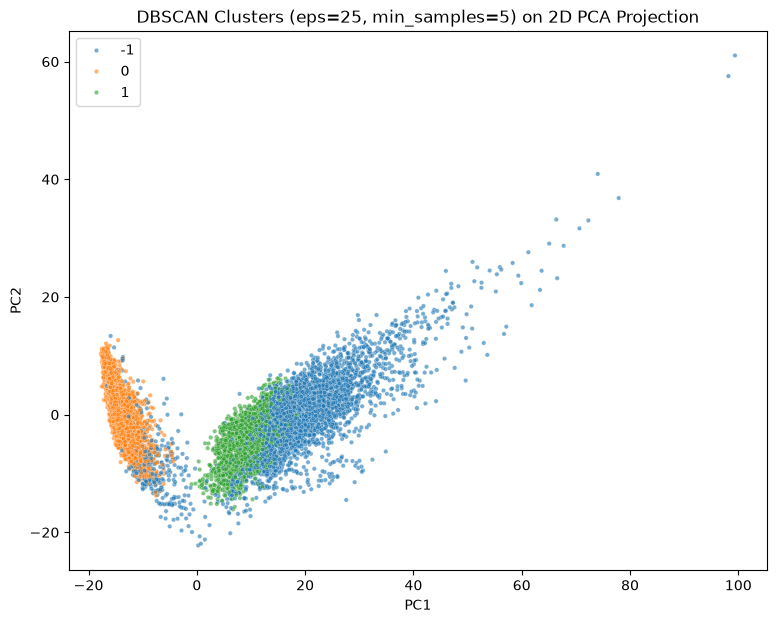

In [30]:
best_db = DBSCAN(eps=11, min_samples=45)
dbscan_labels = best_db.fit_predict(X_pca_50d)

#eps=10, min_samples=10 is alright

plt.figure(figsize=(9, 7))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=dbscan_labels, 
                 palette="tab10", s=10, alpha=0.6, legend="full")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters (eps=25, min_samples=5) on 2D PCA Projection")
plt.show()

In [31]:
crosstab_db = pd.crosstab(dbscan_labels, y_names, rownames=["Cluster"], colnames=["True Activity"])
print(crosstab_db)

True Activity  LAYING  SITTING  STANDING  WALKING  WALKING_DOWNSTAIRS  \
Cluster                                                                 
-1                177      109        61      893                1289   
 0               1767     1668      1845        0                   0   
 1                  0        0         0      829                 117   

True Activity  WALKING_UPSTAIRS  
Cluster                          
-1                          858  
 0                            0  
 1                          686  


##### Supplementary DBSCAN - 6-cluster attempt
For our upcoming algorithm comparison it will be helpful to also plot and obtain a crosstab for a DBSCAN that is trying to cluster the data like our k = 6 K-Means approach.

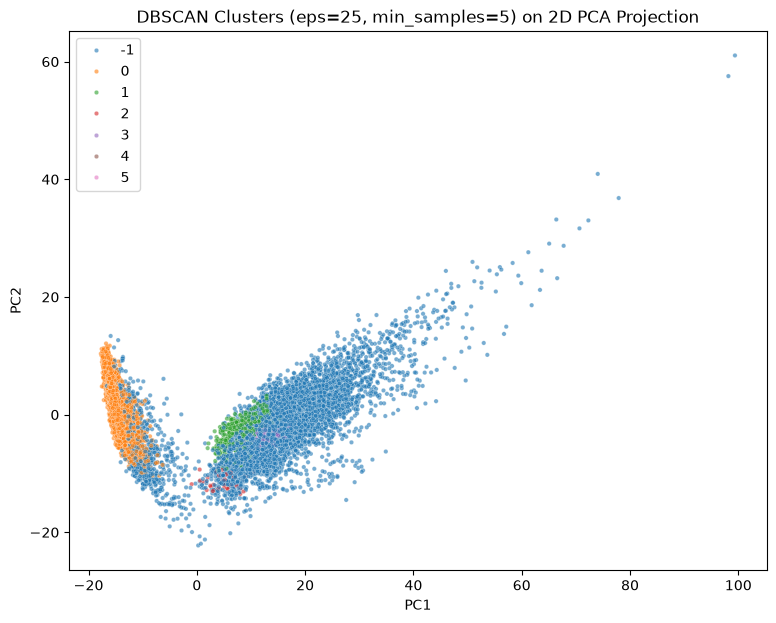

True Activity  LAYING  SITTING  STANDING  WALKING  WALKING_DOWNSTAIRS  \
Cluster                                                                 
-1                362      212       227     1261                1403   
 0               1582     1565      1679        0                   0   
 1                  0        0         0      368                   2   
 2                  0        0         0        0                   1   
 3                  0        0         0       78                   0   
 4                  0        0         0       15                   0   
 5                  0        0         0        0                   0   

True Activity  WALKING_UPSTAIRS  
Cluster                          
-1                         1440  
 0                            0  
 1                           44  
 2                           39  
 3                            0  
 4                            0  
 5                           21  


In [32]:
best_db = DBSCAN(eps=9, min_samples=15)
dbscan_labels = best_db.fit_predict(X_pca_50d)

#eps=10, min_samples=10 is alright

plt.figure(figsize=(9, 7))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=dbscan_labels, 
                 palette="tab10", s=10, alpha=0.6, legend="full")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters (eps=25, min_samples=5) on 2D PCA Projection")
plt.show()

crosstab_db = pd.crosstab(dbscan_labels, y_names, rownames=["Cluster"], colnames=["True Activity"])
print(crosstab_db)

### Step 6) Evaluation and Reflection
##### Which algorithm produced more coherent clusters?
I'll highlight two of our K-means approaches alongside our DBSCAN approach. I added a 4th DBSCAN that attempts 6 clusters for comparison to K-means (k = 6)

| Algorithm | Silhouette Score | Cluster Coherency (from Crosstab) | 
| :--- | :--- | :--- |
| K-Means (k = 2) | 0.4501 | Separates static (LAYING, SITTING, STANDING) and dynamic (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS) | 
| K-Means (k = 6) | 0.1524 | 3 clusters are dynamic and 3 are static. Distinction within those groups starts to appear for 'LAYING', but other clusters do not coherently classify to one label|
| DBSCAN (eps = 11, min_samples = 45) | 0.4731 | Separates static and dynamic, but discards 32.89% of the data as noise. |
| DBSCAN (eps = 9, min_samples = 15) | 0.4192 | Separates out one static cluster, marks ~48% of data as noise (which does, surprisingly, map quite well to dynamic labels), and comes up with 5 more clusters that are too small to be meaningful |
| (Bonus) t-SNE then K-Means (k=6) | 0.4079 | Pleasant surprise! this approach coherently separates and classifies all but two of our labels (SITTING/STANDING)

K-means at k = 2 gives us a clean separation of the clearest distinction in this data, that of static and dynamic data. At k = 6, our silhouette score drops though we maintain the separation of static and dynamic data. We also are able to mostly resolve a meaningful labeled cluster: LAYING. It matches intuition that laying would be the first action category to be separable as it is the most unique-among-its-neighbors action within the static and dynamic actions. 

DBSCAN gives us a higher silhouette score but at the cost of discarding one third of the data as noise. The DBSCAN algorith was harder to use because it had so many more parameter possibilities. My early attempts around eps = 20 mostly collapsed into classifying all points into one group. I filtered for groupings where the second cluster was at least 20% the size of the first, and was able to cluster static vs dynamic, but with one third of the data discarded as noise.

Overall, our k = 6 approach with the K-Means algorithm gave the most coherent clusters, with static + dynamic + LAYING. I didn't explore the full space of what DBSCAN could offer, and different hyperparameters may have returned something more coherent.

##### Did dimensonality reduction improve results or execution time?
Let's check. First let's recall what the 'cost' of our dimensionality reductions in terms of losing information.

Explained variance (2D): [0.50738221 0.06239186] total: 0.5697740681020983
Explained variance (50D total): 0.8709898472528163

Now, let's run a timing experiment.

In [33]:
import time
t0 = time.time()
KMeans(n_clusters=6, random_state=42, n_init=10).fit(X_scaled)
print("561D:", time.time() - t0)

t0 = time.time()
KMeans(n_clusters=6, random_state=42, n_init=10).fit(X_pca_50d)
print("50D:", time.time() - t0)

561D: 0.9169971942901611
50D: 0.1418607234954834


Execution time improved close to proportionally (~10% execution time with ~10% dimensions).

##### How accurately did the unsupervised clusters map to the true activity labels?
Cleanly for dynamic vs static, in rare cases for LAYING, and never for all 6 categories.

(BONUS) The t-SNE approach was able to accurately separate and cluster all but the STANDING/SITTING datapoints.

##### If you did not have access to the ground-truth labels, how would you determine the optimal number of clusters and evaluate your model's success?
The 2D PCA projeection would have been a good start, as it showed the static vs dynamic distinction that was the most meaningful classification we were able to get out of our models. Other 'exploratory' PCAs may also be of use. I was curious to see what a 3D PCA would show, so I explored it an addendum to the document. The two main clumps of datapoints were still dominant, but the dynamic points were farther apart and seemed to 'explode' off in one direction.

Charting the elbow point at eps = 20 for DBSCAN was also helpful, though I found more meaningful groupings at around half that value. Adding the relative size ratio criteria to clusters also helped me get closer to meaningful clusterings, and continuing down that road may have led me to DBSCAN clustering that was more meaningful than what I arrived at here.

Working with two models to compare results also seems essential. (Bonus) And why not three? The t-SNE approach separated datapoints that I had written off as not meaningfully separable.


##### 3D PCA exploration - addendum

In [34]:
# 3 components for 3D visualization
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)
print("Explained variance (3D):", pca_3d.explained_variance_ratio_, 
      "total:", pca_3d.explained_variance_ratio_.sum())

import plotly.express as px

fig = px.scatter_3d(
    x=X_pca_3d[:, 0], y=X_pca_3d[:, 1], z=X_pca_3d[:, 2],
    color=y_names,
    labels={'x': 'PC1', 'y': 'PC2', 'z': 'PC3', 'color': 'Activity'},
    title="3D PCA Projection of HAR Data, Colored by True Activity",
    opacity=0.6
)
fig.update_traces(marker=dict(size=3))
fig.show()
#fig.show(renderer="browser")

Explained variance (3D): [0.50738221 0.06239186 0.02692564] total: 0.5966997067291709


##### Addendum 2 - t-SNE Visualization

In [35]:
from sklearn.manifold import TSNE
import time

# t-SNE on the 50D PCA data (recommended over raw 561D — faster, and PCA pre-reduction 
# is a standard practice to denoise before t-SNE)
t0 = time.time()
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto")
X_tsne = tsne.fit_transform(X_pca_50d)
print(f"t-SNE took {time.time() - t0:.1f} seconds")

t-SNE took 15.1 seconds


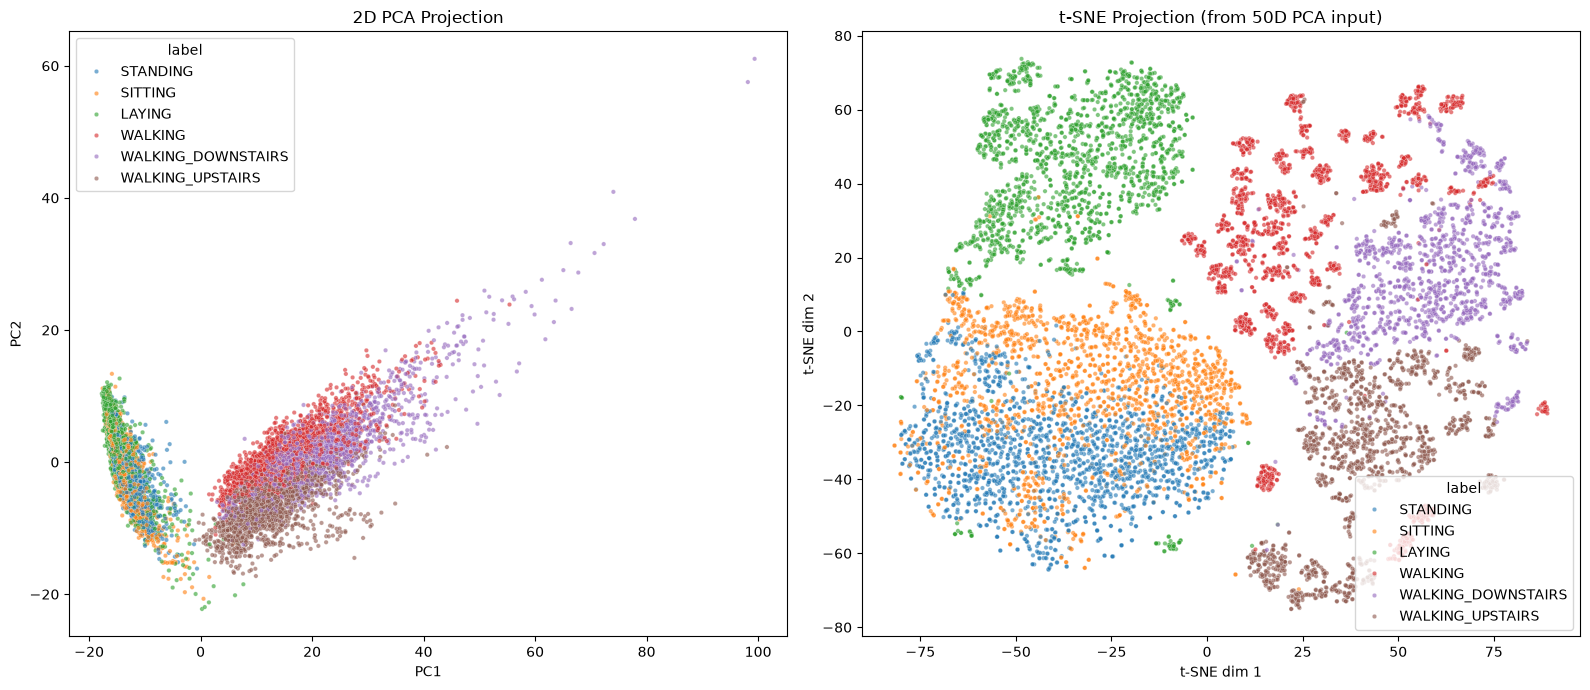

Silhouette (K-Means on t-SNE output): 0.4079
True Activity  LAYING  SITTING  STANDING  WALKING  WALKING_DOWNSTAIRS  \
Cluster                                                                 
0                  57      767      1071        0                   0   
1                  15        0         0     1125                 126   
2                   0        0         0      374                1143   
3                  41      992       835        0                   0   
4                1829       15         0        0                   0   
5                   2        3         0      223                 137   

True Activity  WALKING_UPSTAIRS  
Cluster                          
0                             0  
1                            30  
2                            70  
3                             0  
4                             0  
5                          1444  


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y_names, 
                 palette="tab10", s=10, alpha=0.6, ax=axes[0], legend="full")
axes[0].set_title("2D PCA Projection")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_names, 
                 palette="tab10", s=10, alpha=0.6, ax=axes[1], legend="full")
axes[1].set_title("t-SNE Projection (from 50D PCA input)")
axes[1].set_xlabel("t-SNE dim 1")
axes[1].set_ylabel("t-SNE dim 2")

plt.tight_layout()
plt.show()

kmeans_tsne = KMeans(n_clusters=6, random_state=42, n_init=10)
tsne_cluster_labels = kmeans_tsne.fit_predict(X_tsne)

sil_tsne = silhouette_score(X_tsne, tsne_cluster_labels)
print(f"Silhouette (K-Means on t-SNE output): {sil_tsne:.4f}")

crosstab_tsne = pd.crosstab(tsne_cluster_labels, y_names, rownames=["Cluster"], colnames=["True Activity"])
print(crosstab_tsne)